# Random Forest Prediction of EPVI Indicators

This notebook trains one random forest model per EPVI indicator from satellite-derived freguesia indicators and only the **basic** administrative indicators listed in `data/adm_data_split.json`.

The privately shared EPVI file stays outside git. Detailed administrative indicators remain excluded here; they are reserved for residual analysis.

Model selection now uses spatial folds built from `data/freguesias_to_NUTS3.csv`. The representative fixed NUTS3 holdout chosen in `spatial_test_set_selection.ipynb` is removed before tuning and is used only for final performance estimates.


In [1]:
from __future__ import annotations

import json
import sys
import time
from datetime import datetime
from importlib import import_module, reload
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42


In [2]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
attach_nuts3 = rf_utils.attach_nuts3
build_modeling_table = rf_utils.build_modeling_table
choose_satellite_csv = rf_utils.choose_satellite_csv
id_coverage_summary = rf_utils.id_coverage_summary
load_nuts3_mapping = rf_utils.load_nuts3_mapping
load_prediction_inputs = rf_utils.load_prediction_inputs
make_nuts3_cv_splits = rf_utils.make_nuts3_cv_splits
rmse = rf_utils.rmse
spearman_corr = rf_utils.spearman_corr
split_fixed_nuts3_holdout = rf_utils.split_fixed_nuts3_holdout

PATHS = load_paths()
SAT_CSV, REGENERATED_SAT_CSV, SNAPSHOT_SAT_CSV = choose_satellite_csv(PATHS, repo_data_path, path_value)
ADM_CSV = repo_data_path(PATHS, "all_used_adm_indicators.csv")
ADM_SPLIT_JSON = repo_data_path(PATHS, "adm_data_split.json")
NUTS3_MAPPING_CSV = repo_data_path(PATHS, "freguesias_to_NUTS3.csv")
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")
EPVI_CSV = path_value(PATHS, "epvi_csv")
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT)
print("satellite predictors:", SAT_CSV)
if SAT_CSV == SNAPSHOT_SAT_CSV:
    print("WARNING: regenerated external index CSV was not found; using committed satellite snapshot.")
print("administrative predictors:", ADM_CSV)
print("private EPVI targets:", EPVI_CSV)
print("NUTS3 mapping:", NUTS3_MAPPING_CSV)
print("parish geometry snapshot:", PARISH_GEOMETRY_GEOJSON)
print("model outputs:", MODEL_OUT_DIR)


repo: e:\git_projects\energy_poverty_from_space
satellite predictors: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\indices\freguesia_indices_streaming.csv
administrative predictors: E:\git_projects\energy_poverty_from_space\data\all_used_adm_indicators.csv
private EPVI targets: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\EPVI_results_gouveia_et_al_2019.csv
NUTS3 mapping: E:\git_projects\energy_poverty_from_space\data\freguesias_to_NUTS3.csv
parish geometry snapshot: E:\git_projects\energy_poverty_from_space\data\parishes.geojson
model outputs: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest


In [3]:
inputs = load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=ADM_CSV,
    epvi_csv=EPVI_CSV,
    adm_split_json=ADM_SPLIT_JSON,
)

EPVI_TARGETS = inputs["targets"]
model_df, predictor_cols, constant_cols = build_modeling_table(inputs)
nuts3_mapping = load_nuts3_mapping(NUTS3_MAPPING_CSV)
model_df = attach_nuts3(model_df, nuts3_mapping)
train_df, test_df = split_fixed_nuts3_holdout(model_df)

print("Raw input ID coverage:")
display(id_coverage_summary(inputs))
print("targets:", EPVI_TARGETS)
print("Final modeling rows:", len(model_df))
print("Training rows outside fixed test NUTS3:", len(train_df))
print("Fixed test rows:", len(test_df))
print("Training NUTS3 regions:", train_df["NUTS3"].nunique())
print("Test NUTS3 regions:", sorted(test_df["NUTS3"].unique()))
print("Predictors used after dropping constant/all-missing columns:", len(predictor_cols))
print("Dropped constant/all-missing predictors:", constant_cols)
display(model_df[["ID_norm", "NUTS3", "parish_name", *EPVI_TARGETS]].head())
display(model_df[predictor_cols].isna().mean().sort_values(ascending=False).rename("missing_share").head(20).to_frame())


Raw input ID coverage:


,table,rows,unique_ids,duplicate_ids,missing_ids
0,sat,3092.0,3092,0.0,0.0
1,adm,3093.0,3092,0.0,1.0
2,epvi,3092.0,3092,0.0,0.0
3,common_sat_adm_epvi,NaN,3092,NaN,NaN


targets: ['EPG heating', 'EPG cooling', 'AIAM', 'EPVI heating', 'EPVI cooling']
Final modeling rows: 3092
Training rows outside fixed test NUTS3: 2474
Fixed test rows: 618
Training NUTS3 regions: 21
Test NUTS3 regions: ['PT112', 'PT16B', 'PT16I', 'PT16J']
Predictors used after dropping constant/all-missing columns: 48
Dropped constant/all-missing predictors: ['res_vol_per_capita_p10', 'pop_density_p10', 'ntl_per_res_vol_p10', 'ntl_per_res_vol_p50', 'energy_per_vol_per_capita_p10']


,ID_norm,NUTS3,parish_name,EPG heating,EPG cooling,AIAM,EPVI heating,EPVI cooling
0,010103,PT16D,Aguada de Cima,15,19,13.4,10.8,12.8
1,010109,PT16D,Fermentelos,16,19,13.4,11.3,12.8
2,010112,PT16D,Macinhata do Vouga,16,19,12.4,11.8,13.3
3,010119,PT16D,Valongo do Vouga,16,19,13.8,11.1,12.6
4,010121,PT16D,União das Freguesias de Águeda e Borralha,14,20,13.1,10.5,13.5


,missing_share
extreme_cold,0.106080
extreme_heat,0.106080
cdd_25,0.106080
hdd_18,0.106080
res_ratio,0.017141
standard_delta_pm_25,0.017141
energy_per_vol_per_capita,0.017141
ntl_per_res_vol_p90,0.017141
ntl_per_res_vol_gini,0.017141
energy_per_vol_per_capita_p50,0.017141


## Spatial Split Map

This map shows the fixed spatial test set and the training-region NUTS3 folds used for hyperparameter search. Every parish in one NUTS3 region has the same split label.


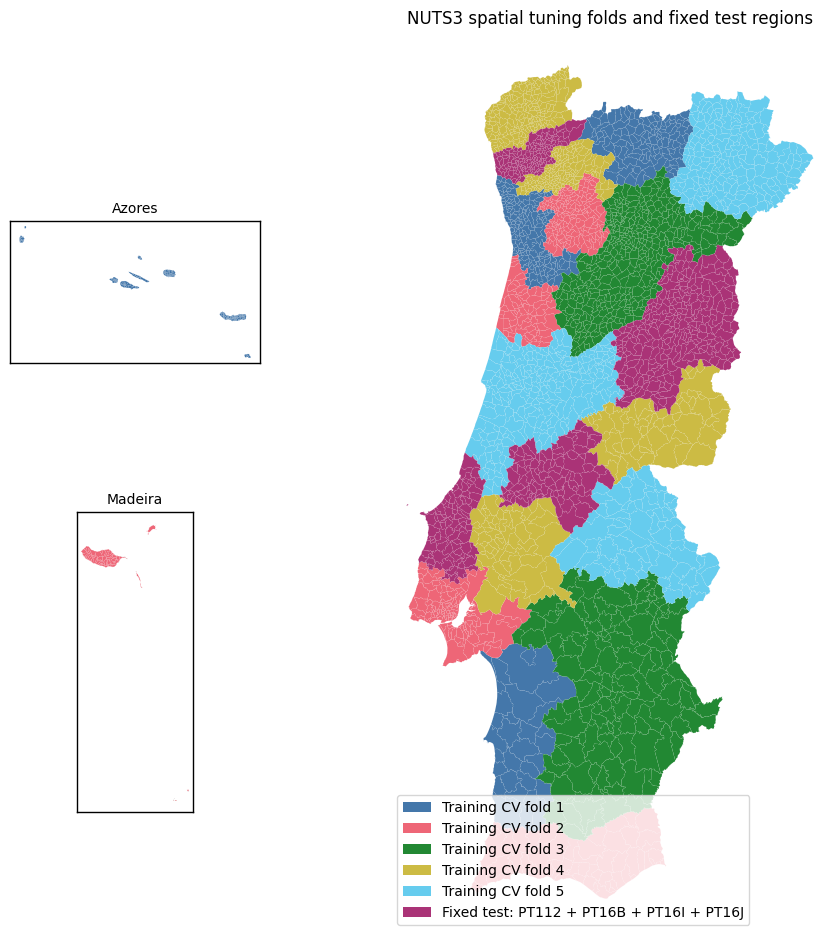

,fold,n_rows,n_nuts3,validation_nuts3
0,0,478,4,"PT11A, PT11B, PT181, PT200"
1,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
2,2,504,4,"PT11D, PT16G, PT184, PT187"
3,3,503,4,"PT111, PT119, PT16H, PT185"
4,4,499,4,"PT11E, PT16E, PT16F, PT186"


In [4]:
split_template_df = train_df.reset_index(drop=True)
_, split_fold_summary = make_nuts3_cv_splits(split_template_df, n_splits=5)
fold_by_nuts3 = {}
for row in split_fold_summary.itertuples(index=False):
    for nuts3 in row.validation_nuts3.split(", "):
        fold_by_nuts3[nuts3] = f"Training CV fold {row.fold + 1}"

split_labels = nuts3_mapping[["ID_norm", "NUTS3"]].drop_duplicates().copy()
split_labels["split_label"] = split_labels["NUTS3"].map(fold_by_nuts3)
test_label = "Fixed test: " + " + ".join(rf_utils.DEFAULT_TEST_NUTS3)
split_labels.loc[split_labels["split_label"].isna(), "split_label"] = test_label

parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
split_map = parishes.merge(split_labels[["ID_norm", "NUTS3", "split_label"]], on="ID_norm", how="left")
if split_map["split_label"].isna().any():
    raise ValueError(f"Split map is missing labels for {split_map['split_label'].isna().sum()} parish geometries.")

split_order = [*(f"Training CV fold {fold}" for fold in range(1, 6)), test_label]
split_colors = {
    "Training CV fold 1": "#4477AA",
    "Training CV fold 2": "#EE6677",
    "Training CV fold 3": "#228833",
    "Training CV fold 4": "#CCBB44",
    "Training CV fold 5": "#66CCEE",
    test_label: "#AA3377",
}

def plot_split_regions(ax, gdf):
    for label in split_order:
        part = gdf.loc[gdf["split_label"].eq(label)]
        if part.empty:
            continue
        part.plot(
            ax=ax,
            color=split_colors[label],
            edgecolor="white",
            linewidth=0.03,
        )
    minx, miny, maxx, maxy = gdf.total_bounds
    padx = (maxx - minx) * 0.04
    pady = (maxy - miny) * 0.04
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_xticks([])
    ax.set_yticks([])

mainland_map = split_map.loc[~split_map["NUTS3"].isin(["PT200", "PT300"])].copy()
azores_map = split_map.loc[split_map["NUTS3"].eq("PT200")].copy()
madeira_map = split_map.loc[split_map["NUTS3"].eq("PT300")].copy()

fig = plt.figure(figsize=(10, 10))
ax_main = fig.add_axes([0.33, 0.05, 0.64, 0.90])
ax_azores = fig.add_axes([0.05, 0.54, 0.25, 0.30], frameon=True)
ax_madeira = fig.add_axes([0.05, 0.17, 0.25, 0.30], frameon=True)

plot_split_regions(ax_main, mainland_map)
plot_split_regions(ax_azores, azores_map)
plot_split_regions(ax_madeira, madeira_map)
ax_main.set_title("NUTS3 spatial tuning folds and fixed test regions")
ax_azores.set_title("Azores", fontsize=10)
ax_madeira.set_title("Madeira", fontsize=10)
for ax in [ax_main, ax_azores, ax_madeira]:
    ax.set_facecolor("white")
ax_main.set_axis_off()
for ax in [ax_azores, ax_madeira]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)
ax_main.legend(
    handles=[Patch(facecolor=split_colors[label], edgecolor="none", label=label) for label in split_order],
    loc="lower left",
    frameon=True,
)
plt.show()

display(split_fold_summary)


## Modeling Design

This notebook runs the second target-aware spatial tuning pass after the representative fixed test set broad search.

The previous broad run showed stable but target-specific regimes: AIAM prefers a deep all-feature forest; EPVI cooling prefers a deep forest with moderate feature subsampling; EPVI heating prefers fewer features and moderate leaf regularization; the EPG targets still transfer weakly and prefer `sqrt` features with stronger leaf regularization. This pass narrows around those regimes while still searching enough nearby options to test whether the broad winners were boundary artifacts.

For each target, hyperparameters are searched only on training NUTS3 regions. Validation folds hold out whole NUTS3 regions and the fold builder keeps `PT200` and `PT300` in different folds when both are present. After tuning, the selected model is evaluated in two distinct ways:

- spatial out-of-fold predictions inside the training regions, used as a tuning diagnostic;
- one final fit on all training regions and one prediction on the fixed representative test set, used for performance analysis.


In [5]:
SPATIAL_CV_FOLDS = 5

preprocess = ColumnTransformer(
    transformers=[("num", SimpleImputer(strategy="median"), predictor_cols)],
    remainder="drop",
    verbose_feature_names_out=False,
)
pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, bootstrap=True)),
])

# Target-aware second pass after the representative fixed-test broad search.
epg_search_space = {
    "model__n_estimators": [500, 800, 1000],
    "model__max_features": ["sqrt", 0.2, 0.35],
    "model__min_samples_leaf": [6, 8, 10, 12, 16, 20],
    "model__min_samples_split": [5, 10, 20, 30, 40],
    "model__max_depth": [6, 8, 12, 18, 24, None],
}
aiam_search_space = {
    "model__n_estimators": [500, 800, 1000],
    "model__max_features": [0.75, 1.0],
    "model__min_samples_leaf": [1, 2, 4],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__max_depth": [18, 24, 32, None],
}
epvi_cooling_search_space = {
    "model__n_estimators": [500, 800, 1000],
    "model__max_features": [0.35, 0.5, 0.75],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__max_depth": [18, 24, 32, None],
}
epvi_heating_search_space = {
    "model__n_estimators": [500, 800, 1000],
    "model__max_features": ["sqrt", 0.2, 0.35, 0.5],
    "model__min_samples_leaf": [2, 4, 6, 8, 10],
    "model__min_samples_split": [5, 10, 20, 30],
    "model__max_depth": [12, 18, 24, 32, None],
}
param_distributions_by_target = {
    "EPG heating": epg_search_space,
    "EPG cooling": epg_search_space,
    "AIAM": aiam_search_space,
    "EPVI heating": epvi_heating_search_space,
    "EPVI cooling": epvi_cooling_search_space,
}
search_candidates_by_target = {target: 36 for target in EPVI_TARGETS}

print("Spatial CV folds:", SPATIAL_CV_FOLDS)
for target in EPVI_TARGETS:
    candidate_space = len(ParameterGrid(param_distributions_by_target[target]))
    n_candidates = search_candidates_by_target[target]
    print(f"{target}: random candidates={n_candidates} | candidate space={candidate_space} | spatial-CV fits={n_candidates * SPATIAL_CV_FOLDS}")


Spatial CV folds: 5
EPG heating: random candidates=36 | candidate space=1620 | spatial-CV fits=180
EPG cooling: random candidates=36 | candidate space=1620 | spatial-CV fits=180
AIAM: random candidates=36 | candidate space=288 | spatial-CV fits=180
EPVI heating: random candidates=36 | candidate space=1200 | spatial-CV fits=180
EPVI cooling: random candidates=36 | candidate space=576 | spatial-CV fits=180


In [6]:
def fmt_seconds(seconds: float) -> str:
    seconds = int(round(seconds))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f"{hours}h {minutes}m {secs}s"
    if minutes:
        return f"{minutes}m {secs}s"
    return f"{secs}s"


def metric_row(prefix: str, y_true, y_pred) -> dict[str, float]:
    return {
        f"{prefix}_r2": r2_score(y_true, y_pred),
        f"{prefix}_mae": mean_absolute_error(y_true, y_pred),
        f"{prefix}_rmse": rmse(y_true, y_pred),
        f"{prefix}_spearman": spearman_corr(y_true, y_pred),
    }

metrics = []
prediction_frames = []
importance_frames = []
fold_frames = []
best_params = {}
all_started = time.perf_counter()

for target_idx, target in enumerate(EPVI_TARGETS, start=1):
    target_started = time.perf_counter()
    train_t = train_df.dropna(subset=[target]).copy().reset_index(drop=True)
    test_t = test_df.dropna(subset=[target]).copy().reset_index(drop=True)
    spatial_cv, fold_summary = make_nuts3_cv_splits(train_t, n_splits=SPATIAL_CV_FOLDS)
    fold_summary.insert(0, "target", target)
    fold_frames.append(fold_summary)

    X_train = train_t[predictor_cols]
    y_train = train_t[target].astype(float)
    X_test = test_t[predictor_cols]
    y_test = test_t[target].astype(float)

    param_distributions = param_distributions_by_target[target]
    search_candidates = search_candidates_by_target[target]

    print("=" * 96, flush=True)
    print(f"[{target_idx}/{len(EPVI_TARGETS)}] Target: {target}", flush=True)
    print(
        f"Train rows={len(train_t):,} | test rows={len(test_t):,} | predictors={len(predictor_cols):,} | "
        f"NUTS3 CV folds={len(spatial_cv)} | search fits={search_candidates * len(spatial_cv):,}",
        flush=True,
    )
    display(fold_summary)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=search_candidates,
        scoring="r2",
        cv=spatial_cv,
        n_jobs=-1,
        refit=True,
        verbose=2,
        random_state=RANDOM_STATE,
    )
    print(f"Starting spatial hyperparameter search at {datetime.now().strftime('%H:%M:%S')}...", flush=True)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    best_params[target] = search.best_params_
    print(f"Best mean spatial-CV search R2={search.best_score_:.4f}", flush=True)
    print("Best params:", best_params[target], flush=True)

    print("Computing spatial out-of-fold predictions on training regions...", flush=True)
    cv_pred = cross_val_predict(best, X_train, y_train, cv=spatial_cv, n_jobs=-1)
    print("Refitting selected model on all training regions and predicting fixed test regions...", flush=True)
    best.fit(X_train, y_train)
    train_pred = best.predict(X_train)
    test_pred = best.predict(X_test)

    row = {
        "target": target,
        "n_train_rows": len(train_t),
        "n_test_rows": len(test_t),
        "n_predictors": len(predictor_cols),
        "search_spatial_cv_r2_mean": search.best_score_,
        **metric_row("train_spatial_cv", y_train, cv_pred),
        **metric_row("fixed_test", y_test, test_pred),
        **metric_row("train_in_sample", y_train, train_pred),
    }
    metrics.append(row)

    for role, data, observed, predicted in [
        ("train_spatial_cv", train_t, y_train, cv_pred),
        ("fixed_test", test_t, y_test, test_pred),
        ("train_in_sample", train_t, y_train, train_pred),
    ]:
        prediction_frames.append(pd.DataFrame({
            "prediction_role": role,
            "target": target,
            "ID": data["ID"].values,
            "ID_norm": data["ID_norm"].values,
            "NUTS3": data["NUTS3"].values,
            "name": data["parish_name"].values,
            "observed": observed.values,
            "predicted": predicted,
            "residual": observed.values - predicted,
        }))

    importance_frames.append(pd.DataFrame({
        "target": target,
        "feature": predictor_cols,
        "impurity_importance": best.named_steps["model"].feature_importances_,
    }).sort_values("impurity_importance", ascending=False))

    target_seconds = time.perf_counter() - target_started
    elapsed_total = time.perf_counter() - all_started
    remaining = elapsed_total / target_idx * (len(EPVI_TARGETS) - target_idx)
    print(pd.Series(row).to_string(), flush=True)
    print(f"Finished in {fmt_seconds(target_seconds)}. Elapsed={fmt_seconds(elapsed_total)} | ETA={fmt_seconds(remaining)}", flush=True)

metrics_df = pd.DataFrame(metrics).sort_values("fixed_test_r2", ascending=False)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
importances_df = pd.concat(importance_frames, ignore_index=True)
folds_df = pd.concat(fold_frames, ignore_index=True)
display(metrics_df)


[1/5] Target: EPG heating
Train rows=2,474 | test rows=618 | predictors=48 | NUTS3 CV folds=5 | search fits=180


,target,fold,n_rows,n_nuts3,validation_nuts3
0,EPG heating,0,478,4,"PT11A, PT11B, PT181, PT200"
1,EPG heating,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
2,EPG heating,2,504,4,"PT11D, PT16G, PT184, PT187"
3,EPG heating,3,503,4,"PT111, PT119, PT16H, PT185"
4,EPG heating,4,499,4,"PT11E, PT16E, PT16F, PT186"


Starting spatial hyperparameter search at 23:15:17...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best mean spatial-CV search R2=0.0905
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 6}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                       EPG heating
n_train_rows                        2474
n_test_rows                          618
n_predictors                          48
search_spatial_cv_r2_mean       0.090546
train_spatial_cv_r2             0.222595
train_spatial_cv_mae            1.039283
train_spatial_cv_rmse           1.602049
train_spatial_cv_spearman       0.505954
fixed_test_r2                   0.001502
fixed_test_mae                  0.956332
fixed_test_rmse                 1.438909
fixed_test_spearman             0.137919
trai

,target,fold,n_rows,n_nuts3,validation_nuts3
0,EPG cooling,0,478,4,"PT11A, PT11B, PT181, PT200"
1,EPG cooling,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
2,EPG cooling,2,504,4,"PT11D, PT16G, PT184, PT187"
3,EPG cooling,3,503,4,"PT111, PT119, PT16H, PT185"
4,EPG cooling,4,499,4,"PT11E, PT16E, PT16F, PT186"


Starting spatial hyperparameter search at 23:20:42...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best mean spatial-CV search R2=0.0378
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 6}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                       EPG cooling
n_train_rows                        2474
n_test_rows                          618
n_predictors                          48
search_spatial_cv_r2_mean       0.037825
train_spatial_cv_r2             0.197139
train_spatial_cv_mae            0.744587
train_spatial_cv_rmse           0.998088
train_spatial_cv_spearman        0.40756
fixed_test_r2                   0.366419
fixed_test_mae                  0.539767
fixed_test_rmse                 0.712319
fixed_test_spearman             0.637837
trai

...

,target,fold,n_rows,n_nuts3,validation_nuts3
0,EPVI heating,0,478,4,"PT11A, PT11B, PT181, PT200"
1,EPVI heating,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
2,EPVI heating,2,504,4,"PT11D, PT16G, PT184, PT187"
3,EPVI heating,3,503,4,"PT111, PT119, PT16H, PT185"
4,EPVI heating,4,499,4,"PT11E, PT16E, PT16F, PT186"


Starting spatial hyperparameter search at 23:43:42...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best mean spatial-CV search R2=0.4166
Best params: {'model__n_estimators': 1000, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.35, 'model__max_depth': 18}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                       EPVI heating
n_train_rows                         2474
n_test_rows                           618
n_predictors                           48
search_spatial_cv_r2_mean        0.416615
train_spatial_cv_r2              0.458777
train_spatial_cv_mae             0.568335
train_spatial_cv_rmse            0.865301
train_spatial_cv_spearman        0.743627
fixed_test_r2                    0.217439
fixed_test_mae                    0.55726
fixed_test_rmse                  0.800399
fixed_test_spearman              0

,target,fold,n_rows,n_nuts3,validation_nuts3
0,EPVI cooling,0,478,4,"PT11A, PT11B, PT181, PT200"
1,EPVI cooling,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
2,EPVI cooling,2,504,4,"PT11D, PT16G, PT184, PT187"
3,EPVI cooling,3,503,4,"PT111, PT119, PT16H, PT185"
4,EPVI cooling,4,499,4,"PT11E, PT16E, PT16F, PT186"


Starting spatial hyperparameter search at 23:52:05...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best mean spatial-CV search R2=0.4293
Best params: {'model__n_estimators': 1000, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 32}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                       EPVI cooling
n_train_rows                         2474
n_test_rows                           618
n_predictors                           48
search_spatial_cv_r2_mean        0.429342
train_spatial_cv_r2              0.480262
train_spatial_cv_mae             0.438244
train_spatial_cv_rmse            0.577971
train_spatial_cv_spearman        0.698312
fixed_test_r2                    0.596784
fixed_test_mae                    0.34384
fixed_test_rmse                  0.451367
fixed_test_spearman              0

,target,n_train_rows,n_test_rows,n_predictors,search_spatial_cv_r2_mean,train_spatial_cv_r2,train_spatial_cv_mae,train_spatial_cv_rmse,train_spatial_cv_spearman,fixed_test_r2,fixed_test_mae,fixed_test_rmse,fixed_test_spearman,train_in_sample_r2,train_in_sample_mae,train_in_sample_rmse,train_in_sample_spearman
2,AIAM,2474,618,48,0.872669,0.876068,0.256628,0.364103,0.939943,0.888005,0.221591,0.308902,0.937995,0.978637,0.097973,0.151170,0.989882
4,EPVI cooling,2474,618,48,0.429342,0.480262,0.438244,0.577971,0.698312,0.596784,0.343840,0.451367,0.783542,0.929976,0.156586,0.212148,0.968576
1,EPG cooling,2474,618,48,0.037825,0.197139,0.744587,0.998088,0.407560,0.366419,0.539767,0.712319,0.637837,0.605737,0.512362,0.699426,0.789723
3,EPVI heating,2474,618,48,0.416615,0.458777,0.568335,0.865301,0.743627,0.217439,0.557260,0.800399,0.522473,0.928868,0.198411,0.313698,0.972752
0,EPG heating,2474,618,48,0.090546,0.222595,1.039283,1.602049,0.505954,0.001502,0.956332,1.438909,0.137919,0.582514,0.793773,1.174014,0.704171


In [7]:
# Optional feature importance diagnostic evaluated on the fixed test set.
RUN_PERMUTATION_IMPORTANCE = False
permutation_frames = []
if RUN_PERMUTATION_IMPORTANCE:
    for target in EPVI_TARGETS:
        train_t = train_df.dropna(subset=[target]).copy()
        test_t = test_df.dropna(subset=[target]).copy()
        best = Pipeline([
            ("prep", preprocess),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, bootstrap=True, **{
                key.replace("model__", ""): value for key, value in best_params[target].items()
            })),
        ])
        best.fit(train_t[predictor_cols], train_t[target].astype(float))
        perm = permutation_importance(
            best,
            test_t[predictor_cols],
            test_t[target].astype(float),
            scoring="r2",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        permutation_frames.append(pd.DataFrame({
            "target": target,
            "feature": predictor_cols,
            "permutation_importance_mean": perm.importances_mean,
            "permutation_importance_std": perm.importances_std,
        }).sort_values("permutation_importance_mean", ascending=False))
permutation_df = pd.concat(permutation_frames, ignore_index=True) if permutation_frames else pd.DataFrame()
if not permutation_df.empty:
    display(permutation_df.groupby("target").head(15))


In [8]:
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
metrics_path = MODEL_OUT_DIR / f"rf_epvi_metrics_{stamp}.csv"
predictions_path = MODEL_OUT_DIR / f"rf_epvi_predictions_residuals_{stamp}.csv"
importances_path = MODEL_OUT_DIR / f"rf_epvi_feature_importances_{stamp}.csv"
params_path = MODEL_OUT_DIR / f"rf_epvi_best_params_{stamp}.json"
folds_path = MODEL_OUT_DIR / f"rf_epvi_spatial_cv_folds_{stamp}.csv"

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
importances_df.to_csv(importances_path, index=False)
folds_df.to_csv(folds_path, index=False)
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)

if not permutation_df.empty:
    permutation_path = MODEL_OUT_DIR / f"rf_epvi_permutation_importances_{stamp}.csv"
    permutation_df.to_csv(permutation_path, index=False)
else:
    permutation_path = None

print("Wrote:")
for path in [metrics_path, predictions_path, importances_path, params_path, folds_path, permutation_path]:
    if path is not None:
        print(" -", path)


Wrote:
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_20260526_000504.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_20260526_000504.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_20260526_000504.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_20260526_000504.json
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_20260526_000504.csv


## Next Step

Use the fixed-test metrics for model performance reporting. Use the training-region spatial-CV metrics to decide whether another narrower tuning pass is warranted, and inspect fixed-test residuals before moving detailed administrative indicators into the residual-explanation stage.
